In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc
import time
import sys
import pybamm
import importlib

sys.path.append('..')
import plot_settings
plot_settings.apply()


import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm_ver3
importlib.reload(exp_pybamm_ver3)

import SPM_eqs
importlib.reload(SPM_eqs)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'SPM_eqs' from '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/symbol/SPM_eqs.py'>

In [2]:
#sol, model,_,params = exp_pybamm_ver3.generate_data(model='SPM', RNG = False)
sol, model,params = sim_PyBaMM.simulate(0.1)
t = np.linspace(0,sol['Time [s]'].entries[-1],1000)
V_true = sol.observe(model.variables['Terminal voltage [V]'])(t)
I = sol.observe(model.variables['Current [A]'])(t)
ocp_p = sol.observe(model.variables['X-averaged positive electrode open-circuit potential [V]'])(t)
ocp_n = sol.observe(model.variables['X-averaged negative electrode open-circuit potential [V]'])(t)
cn = sol.observe(model.variables['X-averaged negative particle concentration [mol.m-3]'])(t)[-1,:]
cp = sol.observe(model.variables['X-averaged positive particle concentration [mol.m-3]'])(t)[-1,:]
jn0_true = sol.observe(model.variables['X-averaged negative electrode exchange current density [A.m-2]'])(t)
jp0_true = sol.observe(model.variables['X-averaged positive electrode exchange current density [A.m-2]'])(t)
OCV_true = sol.observe(model.variables['Surface open-circuit voltage [V]'])(t)

In [3]:
cn_norm = cn / params['Maximum concentration in negative electrode [mol.m-3]']
cp_norm = cp / params['Maximum concentration in positive electrode [mol.m-3]']

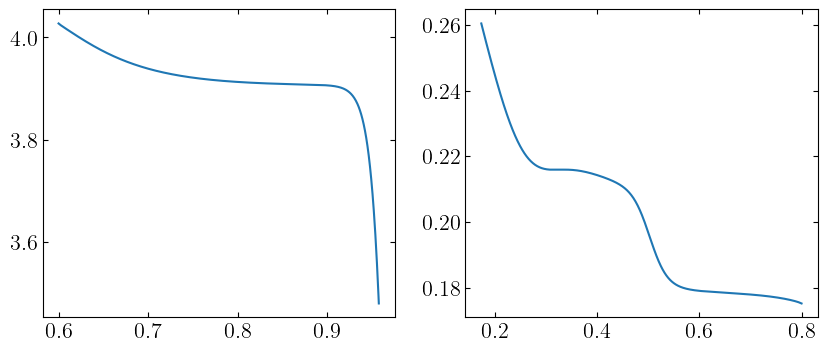

In [4]:
f, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(cp_norm, ocp_p, label='Positive Electrode')
ax[1].plot(cn_norm, ocp_n, label='Negative Electrode')


In [5]:
from pysr import PySRRegressor
from pysr import jl
jl.seval("using Statistics")

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [6]:

cn_norm = cn_norm.reshape(-1,1)
cp_norm = cp_norm.reshape(-1,1)
ocp_n = ocp_n.reshape(-1,1)
ocp_p = ocp_p.reshape(-1,1)

print(cn_norm.shape, ocp_n.shape)
print(cp_norm.shape, ocp_p.shape)

(1000, 1) (1000, 1)
(1000, 1) (1000, 1)


In [7]:
model = PySRRegressor(
    model_selection="best",  # "best" or "accuracy"
    niterations=100,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "log", "sqrt","square","cube"],
    loss="loss(x, y) = mean(abs(x - y))",
    populations=10,
    verbosity=1,)



/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(


In [8]:
model.fit(cn_norm, ocp_n)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 1.160e+05
Progress: 614 / 1000 total iterations (61.400%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.966e-02  0.000e+00  y = 0.20642
4           1.221e-02  1.586e-01  y = 0.31703 / exp(x₀)
5           5.386e-03  8.187e-01  y = 0.34776 / (x₀ + 1.2688)
6           5.202e-03  3.479e-02  y = 0.26112 / (sqrt(x₀) + 0.63548)
8           5.181e-03  2.075e-03  y = 0.28332 / (sqrt(x₀ + -0.060556) + 0.79646)
11          5.134e-03  3.027e-03  y = (exp(square(0.96962 - x₀)) + (x₀ / x₀)) * 0.085574
14          4.894e-03  1.597e-02  y = exp(((x₀ - -1.053) * (2.0659 - (x₀ / 0.69005))) / (x₀ ...
                                      - 1.766))
22          4.602e-03  7.685e-03  y = exp(log((x₀ / x₀) + exp(log(log(x₀ - cube(log(x₀) * 1....
                    

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '-', ...]"
,unary_operators,"['exp', 'log', ...]"
,expression_spec,None
,niterations,100
,populations,10
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


  - outputs/20260225_155039_cPGFed/hall_of_fame.csv


In [ ]:
model.get_best()

'0.422 \\log{\\left(\\left(\\log{\\left(0.883 x_{0} - 1.62 \\log{\\left(x_{0} \\right)}^{3} \\right)} + 0.768\\right)^{0.103} + 1 \\right)}^{2}'